# Visualize BraTS 2023 Dataset Samples
This notebook visualizes the 4 MRI modalities (`t1n`, `t1c`, `t2w`, `t2f`) and the segmentation mask for a single slice of a patient's brain volume using `nibabel`.


Found 1251 patient directories.
Visualizing patient: BraTS-GLI-00000-000


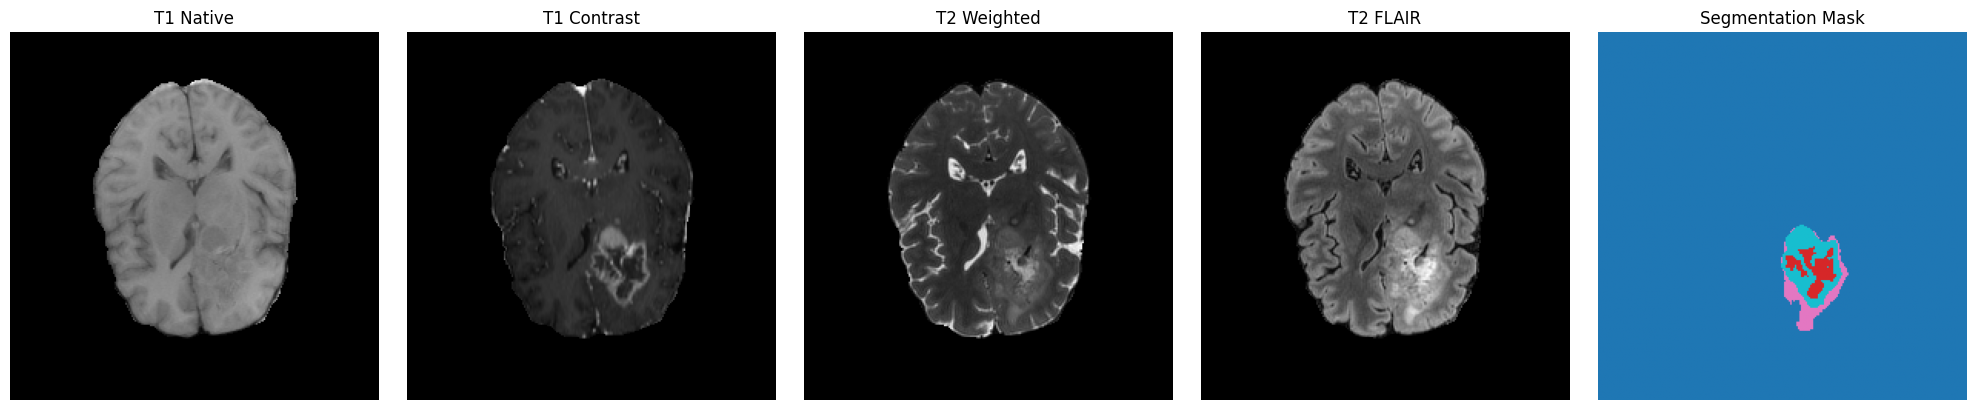

In [3]:
import os
import nibabel as nib
import matplotlib.pyplot as plt
import numpy as np
import glob

# Constants
DATA_DIR = "../../dataset/brats2023/ASNR-MICCAI-BraTS2023-GLI-Challenge-TrainingData"

def get_volume_paths(data_dir):
    # BraTS structure typically has subdirectories for each patient
    # In each subdirectory, we have files ending with -t1n.nii.gz, -t2f.nii.gz, etc.
    patient_dirs = [os.path.join(data_dir, d) for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, d))]
    return patient_dirs

patient_dirs = get_volume_paths(DATA_DIR)
print(f"Found {len(patient_dirs)} patient directories.")

if len(patient_dirs) > 0:
    sample_patient = patient_dirs[0]
    print(f"Visualizing patient: {os.path.basename(sample_patient)}")
    
    # Locate modality files
    t1n_path = glob.glob(os.path.join(sample_patient, "*-t1n.nii*"))[0]
    t1c_path = glob.glob(os.path.join(sample_patient, "*-t1c.nii*"))[0]
    t2w_path = glob.glob(os.path.join(sample_patient, "*-t2w.nii*"))[0]
    t2f_path = glob.glob(os.path.join(sample_patient, "*-t2f.nii*"))[0]
    seg_path = glob.glob(os.path.join(sample_patient, "*-seg.nii*"))[0]
    
    # Load data
    t1n = nib.load(t1n_path).get_fdata()
    t1c = nib.load(t1c_path).get_fdata()
    t2w = nib.load(t2w_path).get_fdata()
    t2f = nib.load(t2f_path).get_fdata()
    seg = nib.load(seg_path).get_fdata()
    
    # Select a mid-slice (Z-axis)
    z_slice = t1n.shape[2] // 2
    
    fig, axes = plt.subplots(1, 5, figsize=(20, 4))
    
    axes[0].imshow(t1n[:, :, z_slice].T, cmap='gray', origin='lower')
    axes[0].set_title('T1 Native')
    axes[0].axis('off')
    
    axes[1].imshow(t1c[:, :, z_slice].T, cmap='gray', origin='lower')
    axes[1].set_title('T1 Contrast')
    axes[1].axis('off')
    
    axes[2].imshow(t2w[:, :, z_slice].T, cmap='gray', origin='lower')
    axes[2].set_title('T2 Weighted')
    axes[2].axis('off')
    
    axes[3].imshow(t2f[:, :, z_slice].T, cmap='gray', origin='lower')
    axes[3].set_title('T2 FLAIR')
    axes[3].axis('off')
    
    # Original Seg classes: 1 (NCR), 2 (ED), 3 (ET)
    axes[4].imshow(seg[:, :, z_slice].T, cmap='tab10', origin='lower')
    axes[4].set_title('Segmentation Mask')
    axes[4].axis('off')
    
    plt.tight_layout()
    plt.show()
else:
    print("No patient directories found. Check your DATA_DIR.")
